In [ ]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install -q transformers datasets evaluate seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
!pip install -q pytorch-crf

# 1. Mô tả bộ dữ liệu



## 1.1. Nguồn dữ liệu

Bộ dữ liệu được xây dựng từ các bản án hình sự về ma túy bằng tiếng Việt. Các bản án được thu thập từ nguồn công khai, sau đó được chuyển đổi từ định dạng PDF sang văn bản để phục vụ quá trình tiền xử lý và gán nhãn.

Các văn bản trong bộ dữ liệu thuộc nhóm bản án hình sự liên quan đến các tội phạm về ma túy như tàng trữ, mua bán, vận chuyển, tổ chức sử dụng hoặc sử dụng trái phép chất ma túy.

## 1.2. Phạm vi dữ liệu

Trong đề tài này, dữ liệu không sử dụng toàn bộ nội dung bản án một cách nguyên vẹn mà tập trung vào các phần có chứa thông tin quan trọng phục vụ bài toán nhận diện thực thể. Các phần được ưu tiên khai thác gồm:

- Nội dung vụ án
- Nhận định của Tòa án
- Quyết định của bản án

Các phần ít liên quan như tiêu ngữ, số trang, nơi nhận, án phí hoặc thông tin thủ tục không phục vụ trực tiếp cho nhiệm vụ NER được loại bỏ trong quá trình tiền xử lý.

## 1.3. Cấu trúc dữ liệu sau tiền xử lý

Sau khi tiền xử lý, mỗi mẫu dữ liệu là một câu hoặc một đoạn văn bản ngắn được trích từ bản án. Việc chia văn bản thành các đoạn ngắn giúp mô hình tập trung vào các thông tin có chứa thực thể cần nhận diện, đồng thời giảm nhiễu so với việc đưa toàn bộ bản án dài vào huấn luyện.

Mỗi mẫu dữ liệu bao gồm hai thành phần chính:

- `text`: nội dung văn bản cần gán nhãn
- `labels`: danh sách các thực thể được gán nhãn theo vị trí bắt đầu, vị trí kết thúc và tên nhãn

In [ ]:
import json
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/NER_NLP_3/data/annotated/drug.jsonl")

records = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

print("Số mẫu dữ liệu:", len(records))
records[0]

Số mẫu dữ liệu: 2673


{'text': 'Tại đây Thào A D gặp và mua được của một người đàn ông trung niên dân tộc Mông không biết tên, địa chỉ 01 gói ma túy Heroine với giá 50.000 đồng.',
 'labels': [[117, 124, 'DRUG']],
 'meta': {'source': 'Bản án số 01 ngày 08012026',
  'section': 'noi_dung',
  'split': 'positive',
  'ner_targets': ['DRUG', 'DRUG_WEIGHT', 'CRIME_TIME', 'CRIME_LOC'],
  'para_idx': 1,
  'record_idx': 1}}

## 1.4. Hệ thống nhãn sử dụng

Bộ dữ liệu được gán nhãn theo 8 loại thực thể chính. Các nhãn này được xây dựng dựa trên đặc điểm của bản án hình sự về ma túy và mục tiêu trích xuất thông tin quan trọng trong văn bản pháp lý.

In [ ]:
import pandas as pd

label_description = pd.DataFrame([
    {"Nhãn": "PERSON", "Ý nghĩa": "Tên bị cáo trong bản án"},
    {"Nhãn": "DRUG", "Ý nghĩa": "Loại ma túy liên quan đến vụ án"},
    {"Nhãn": "DRUG_WEIGHT", "Ý nghĩa": "Khối lượng ma túy"},
    {"Nhãn": "CRIME_TIME", "Ý nghĩa": "Thời gian thực hiện hành vi phạm tội"},
    {"Nhãn": "CRIME_LOC", "Ý nghĩa": "Địa điểm xảy ra hành vi phạm tội"},
    {"Nhãn": "CHARGE", "Ý nghĩa": "Tội danh được Tòa án tuyên"},
    {"Nhãn": "SENTENCE", "Ý nghĩa": "Hình phạt chính hoặc hình phạt bổ sung"},
    {"Nhãn": "LEGAL_ARTICLE", "Ý nghĩa": "Điều, khoản, điểm của Bộ luật Hình sự được áp dụng"},
])

label_description

,Nhãn,Ý nghĩa
0,PERSON,Tên bị cáo trong bản án
1,DRUG,Loại ma túy liên quan đến vụ án
2,DRUG_WEIGHT,Khối lượng ma túy
3,CRIME_TIME,Thời gian thực hiện hành vi phạm tội
4,CRIME_LOC,Địa điểm xảy ra hành vi phạm tội
5,CHARGE,Tội danh được Tòa án tuyên
6,SENTENCE,Hình phạt chính hoặc hình phạt bổ sung
7,LEGAL_ARTICLE,"Điều, khoản, điểm của Bộ luật Hình sự được áp ..."


## 1.5. Định dạng dữ liệu gán nhãn

Dữ liệu ban đầu được gán nhãn theo định dạng JSONL của Doccano. Trong đó, mỗi dòng là một mẫu dữ liệu độc lập. Mỗi thực thể được biểu diễn bằng vị trí bắt đầu, vị trí kết thúc và loại nhãn.

Đối với các mô hình transformer như PhoBERT và XLM-RoBERTa, dữ liệu sau đó được chuyển sang định dạng BIO để phục vụ huấn luyện bài toán token classification.

In [ ]:
sample = records[0]

print("Text:")
print(sample["text"])

print("\nLabels:")
for start, end, label in sample.get("labels", []):
    print(start, end, label, "=>", sample["text"][start:end])

Text:
Tại đây Thào A D gặp và mua được của một người đàn ông trung niên dân tộc Mông không biết tên, địa chỉ 01 gói ma túy Heroine với giá 50.000 đồng.

Labels:
117 124 DRUG => Heroine


## 1.6. Đặc điểm của bộ dữ liệu

Bộ dữ liệu có một số đặc điểm đáng chú ý:

Thứ nhất, văn bản bản án hình sự có cấu trúc pháp lý đặc thù, thường chứa nhiều câu dài, nhiều cụm pháp lý và cách diễn đạt mang tính khuôn mẫu.

Thứ hai, một số thực thể có ranh giới ngắn và dễ nhận diện như DRUG hoặc DRUG_WEIGHT, trong khi một số thực thể khác có ranh giới dài và phụ thuộc nhiều vào ngữ cảnh như CRIME_LOC, SENTENCE hoặc LEGAL_ARTICLE.

Thứ ba, phân bố giữa các nhãn không đồng đều. Một số nhãn xuất hiện với tần suất cao hơn, trong khi một số nhãn như CHARGE hoặc SENTENCE thường có số lượng ít hơn. Điều này có thể ảnh hưởng đến khả năng học của mô hình đối với từng loại thực thể.

# 2. Thống kê tổng quan bộ dữ liệu

## 2.1. Tổng số mẫu dữ liệu


In [ ]:
import json
import pandas as pd
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/NER_NLP_3/data/annotated/drug.jsonl")

records = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

num_records = len(records)

print("Tổng số mẫu dữ liệu:", num_records)

Tổng số mẫu dữ liệu: 2673


## 2.2. Tổng số thực thể

In [ ]:
def get_labels(record):
    if "labels" in record:
        return record["labels"]
    if "label" in record:
        return record["label"]
    if "entities" in record:
        return record["entities"]
    return []


total_entities = 0

for record in records:
    total_entities += len(get_labels(record))

print("Tổng số thực thể:", total_entities)
print("Trung bình thực thể / mẫu:", round(total_entities / num_records, 2))

Tổng số thực thể: 3268
Trung bình thực thể / mẫu: 1.22


## 2.3. Số lượng thực thể theo từng nhãn

In [ ]:
from collections import Counter

LABEL_ORDER = [
    "PERSON",
    "DRUG",
    "DRUG_WEIGHT",
    "CRIME_TIME",
    "CRIME_LOC",
    "CHARGE",
    "SENTENCE",
    "LEGAL_ARTICLE",
]

label_counter = Counter()

for record in records:
    for ent in get_labels(record):
        if isinstance(ent, list) and len(ent) >= 3:
            label = ent[2]
        elif isinstance(ent, dict):
            label = ent.get("label") or ent.get("entity")
        else:
            continue

        if label in LABEL_ORDER:
            label_counter[label] += 1

label_stats = []

for label in LABEL_ORDER:
    count = label_counter[label]
    ratio = count / total_entities * 100 if total_entities > 0 else 0

    label_stats.append({
        "Nhãn": label,
        "Số lượng": count,
        "Tỷ lệ (%)": ratio,
    })

label_stats_df = pd.DataFrame(label_stats)

label_stats_df

,Nhãn,Số lượng,Tỷ lệ (%)
0,PERSON,445,13.616891
1,DRUG,872,26.682987
2,DRUG_WEIGHT,244,7.466340
3,CRIME_TIME,341,10.434517
4,CRIME_LOC,235,7.190942
5,CHARGE,229,7.007344
6,SENTENCE,228,6.976744
7,LEGAL_ARTICLE,674,20.624235


## 2.4. Tỷ lệ phân bố nhãn

In [ ]:
label_stats_df["Tỷ lệ (%)"] = label_stats_df["Số lượng"] / label_stats_df["Số lượng"].sum() * 100

label_stats_df = label_stats_df.sort_values("Số lượng", ascending=False).reset_index(drop=True)

label_stats_df.style.format({
    "Tỷ lệ (%)": "{:.2f}%"
})

,Nhãn,Số lượng,Tỷ lệ (%)
0,DRUG,872,26.68%
1,LEGAL_ARTICLE,674,20.62%
2,PERSON,445,13.62%
3,CRIME_TIME,341,10.43%
4,DRUG_WEIGHT,244,7.47%
5,CRIME_LOC,235,7.19%
6,CHARGE,229,7.01%
7,SENTENCE,228,6.98%


## 2.5. Biểu đồ phân bố nhãn

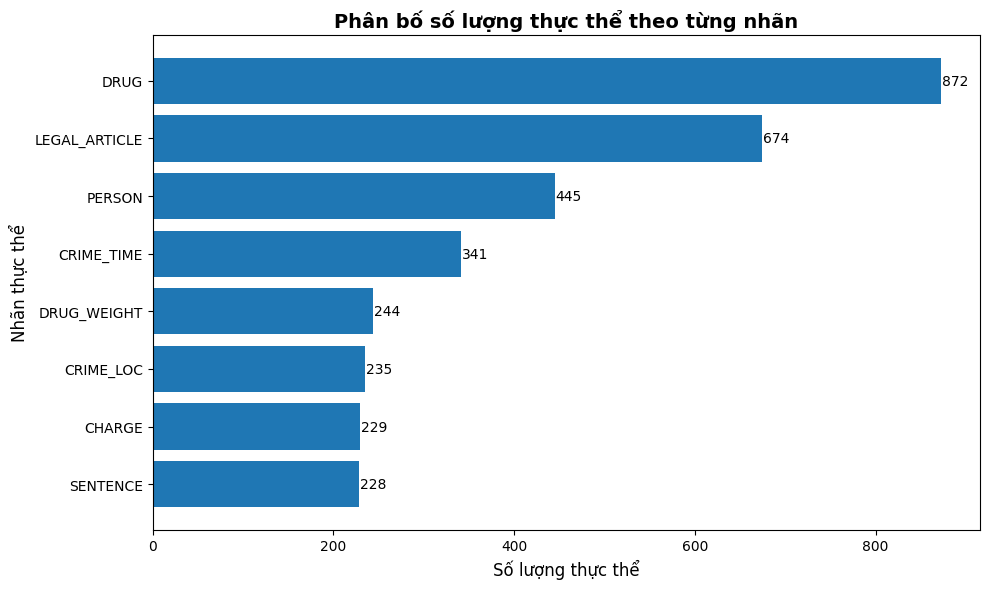

In [ ]:
import matplotlib.pyplot as plt

plot_df = label_stats_df.sort_values("Số lượng", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(plot_df["Nhãn"], plot_df["Số lượng"])

plt.xlabel("Số lượng thực thể", fontsize=12)
plt.ylabel("Nhãn thực thể", fontsize=12)
plt.title("Phân bố số lượng thực thể theo từng nhãn", fontsize=14, fontweight="bold")

for i, value in enumerate(plot_df["Số lượng"]):
    plt.text(value + 1, i, str(value), va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 2.6. Bảng tổng hợp mô tả dataset

In [ ]:
dataset_summary = pd.DataFrame([
    {
        "Chỉ tiêu": "Tổng số mẫu dữ liệu",
        "Giá trị": num_records,
    },
    {
        "Chỉ tiêu": "Tổng số thực thể",
        "Giá trị": total_entities,
    },
    {
        "Chỉ tiêu": "Số loại nhãn",
        "Giá trị": len(LABEL_ORDER),
    },
    {
        "Chỉ tiêu": "Trung bình thực thể / mẫu",
        "Giá trị": round(total_entities / num_records, 2),
    },
    {
        "Chỉ tiêu": "Nhãn xuất hiện nhiều nhất",
        "Giá trị": label_stats_df.iloc[0]["Nhãn"],
    },
    {
        "Chỉ tiêu": "Nhãn xuất hiện ít nhất",
        "Giá trị": label_stats_df.iloc[-1]["Nhãn"],
    },
])

dataset_summary

,Chỉ tiêu,Giá trị
0,Tổng số mẫu dữ liệu,2673
1,Tổng số thực thể,3268
2,Số loại nhãn,8
3,Trung bình thực thể / mẫu,1.22
4,Nhãn xuất hiện nhiều nhất,DRUG
5,Nhãn xuất hiện ít nhất,SENTENCE


## 2.7. Nhận xét về phân bố dữ liệu

Từ kết quả thống kê, có thể nhận thấy bộ dữ liệu có sự chênh lệch về số lượng giữa các nhãn thực thể. Một số nhãn xuất hiện với tần suất cao hơn, trong khi một số nhãn có số lượng ít hơn. Điều này phản ánh đặc điểm tự nhiên của văn bản bản án hình sự về ma túy, trong đó các thông tin như tên bị cáo, loại ma túy hoặc điều luật thường xuất hiện nhiều lần, còn các thông tin như tội danh hoặc hình phạt thường xuất hiện tập trung ở phần quyết định của bản án.

Sự mất cân bằng giữa các nhãn có thể ảnh hưởng đến kết quả huấn luyện mô hình. Các nhãn có số lượng lớn thường giúp mô hình học được đặc trưng ổn định hơn, trong khi các nhãn có số lượng ít dễ bị nhận diện sai hoặc bỏ sót. Vì vậy, việc thống kê phân bố nhãn là cần thiết để hỗ trợ phân tích kết quả thực nghiệm ở các phần sau.

# 3. Thống kê tập train/dev/test

In [ ]:
%cd "/content/drive/MyDrive/NER_NLP_3/src"
!python make_shared_split.py \
  --data ../data/annotated/drug.jsonl \
  --output ../data/splits/shared \
  --seed 42 \
  --train-ratio 0.85 \
  --dev-ratio 0.10

/content/drive/MyDrive/NER_NLP_3/src
Đã tạo shared split:
- Train: ../data/splits/shared/train.jsonl | records=2303
- Dev  : ../data/splits/shared/dev.jsonl | records=264
- Test : ../data/splits/shared/test.jsonl | records=106
- Report: ../data/splits/shared/split_report.json


## 3.1. Đọc dữ liệu split chung

In [ ]:
import json
import pandas as pd
from pathlib import Path
from collections import Counter

SPLIT_DIR = Path("/content/drive/MyDrive/NER_NLP_3/data/splits/shared")

TRAIN_PATH = SPLIT_DIR / "train.jsonl"
DEV_PATH = SPLIT_DIR / "dev.jsonl"
TEST_PATH = SPLIT_DIR / "test.jsonl"

def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

train_records = load_jsonl(TRAIN_PATH)
dev_records = load_jsonl(DEV_PATH)
test_records = load_jsonl(TEST_PATH)

print("Train:", len(train_records))
print("Dev  :", len(dev_records))
print("Test :", len(test_records))

Train: 2303
Dev  : 264
Test : 106


## 3.2. Thống kê số mẫu trong train/dev/test

In [ ]:
split_sample_stats = pd.DataFrame([
    {"Tập dữ liệu": "Train", "Số mẫu": len(train_records)},
    {"Tập dữ liệu": "Dev", "Số mẫu": len(dev_records)},
    {"Tập dữ liệu": "Test", "Số mẫu": len(test_records)},
])

total_samples = split_sample_stats["Số mẫu"].sum()
split_sample_stats["Tỷ lệ (%)"] = split_sample_stats["Số mẫu"] / total_samples * 100

split_sample_stats.style.format({
    "Tỷ lệ (%)": "{:.2f}%"
}).set_properties(**{
    "text-align": "center",
    "font-size": "14px",
    "padding": "6px",
})

,Tập dữ liệu,Số mẫu,Tỷ lệ (%)
0,Train,2303,86.16%
1,Dev,264,9.88%
2,Test,106,3.97%


## 3.3. Thống kê số thực thể trong train/dev/test

In [ ]:
LABEL_ORDER = [
    "PERSON",
    "DRUG",
    "DRUG_WEIGHT",
    "CRIME_TIME",
    "CRIME_LOC",
    "CHARGE",
    "SENTENCE",
    "LEGAL_ARTICLE",
]

def get_labels(record):
    if "labels" in record:
        return record["labels"]
    if "label" in record:
        return record["label"]
    if "entities" in record:
        return record["entities"]
    return []

def count_entities(records):
    total = 0

    for record in records:
        total += len(get_labels(record))

    return total

train_entities = count_entities(train_records)
dev_entities = count_entities(dev_records)
test_entities = count_entities(test_records)

split_entity_stats = pd.DataFrame([
    {"Tập dữ liệu": "Train", "Số mẫu": len(train_records), "Số thực thể": train_entities},
    {"Tập dữ liệu": "Dev", "Số mẫu": len(dev_records), "Số thực thể": dev_entities},
    {"Tập dữ liệu": "Test", "Số mẫu": len(test_records), "Số thực thể": test_entities},
])

total_entities_split = split_entity_stats["Số thực thể"].sum()
split_entity_stats["Tỷ lệ thực thể (%)"] = split_entity_stats["Số thực thể"] / total_entities_split * 100
split_entity_stats["Trung bình thực thể / mẫu"] = split_entity_stats["Số thực thể"] / split_entity_stats["Số mẫu"]

split_entity_stats.style.format({
    "Tỷ lệ thực thể (%)": "{:.2f}%",
    "Trung bình thực thể / mẫu": "{:.2f}",
}).set_properties(**{
    "text-align": "center",
    "font-size": "14px",
    "padding": "6px",
})

,Tập dữ liệu,Số mẫu,Số thực thể,Tỷ lệ thực thể (%),Trung bình thực thể / mẫu
0,Train,2303,2793,85.47%,1.21
1,Dev,264,366,11.20%,1.39
2,Test,106,109,3.34%,1.03


## 3.4. Thống kê từng nhãn trong train/dev/test

In [ ]:
def count_entities_by_label(records):
    counter = Counter()

    for record in records:
        for ent in get_labels(record):
            if isinstance(ent, list) and len(ent) >= 3:
                label = ent[2]
            elif isinstance(ent, dict):
                label = ent.get("label") or ent.get("entity")
            else:
                continue

            if label in LABEL_ORDER:
                counter[label] += 1

    return counter

train_label_counter = count_entities_by_label(train_records)
dev_label_counter = count_entities_by_label(dev_records)
test_label_counter = count_entities_by_label(test_records)

rows = []

for label in LABEL_ORDER:
    train_count = train_label_counter[label]
    dev_count = dev_label_counter[label]
    test_count = test_label_counter[label]
    total = train_count + dev_count + test_count

    rows.append({
        "Nhãn": label,
        "Train": train_count,
        "Dev": dev_count,
        "Test": test_count,
        "Tổng": total,
    })

split_label_stats_df = pd.DataFrame(rows)

split_label_stats_df.style.set_properties(**{
    "text-align": "center",
    "font-size": "14px",
    "padding": "6px",
})

,Nhãn,Train,Dev,Test,Tổng
0,PERSON,371,55,19,445
1,DRUG,782,72,18,872
2,DRUG_WEIGHT,200,36,8,244
3,CRIME_TIME,298,33,10,341
4,CRIME_LOC,197,27,11,235
5,CHARGE,185,35,9,229
6,SENTENCE,187,34,7,228
7,LEGAL_ARTICLE,573,74,27,674


## 3.5. Biểu đồ số thực thể theo train/dev/test


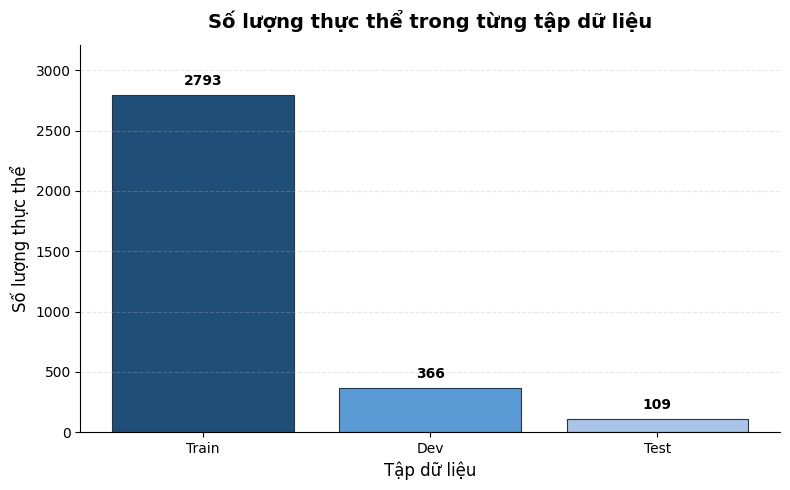

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    split_entity_stats["Tập dữ liệu"],
    split_entity_stats["Số thực thể"],
    color=["#1F4E79", "#5B9BD5", "#A9C4E8"],
    edgecolor="#333333",
    linewidth=0.8
)

plt.xlabel("Tập dữ liệu", fontsize=12)
plt.ylabel("Số lượng thực thể", fontsize=12)
plt.title(
    "Số lượng thực thể trong từng tập dữ liệu",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(split_entity_stats["Số thực thể"]) * 0.02,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylim(0, max(split_entity_stats["Số thực thể"]) * 1.15)

plt.tight_layout()
plt.show()

## 3.6. Biểu đồ phân bố từng nhãn theo train/dev/test

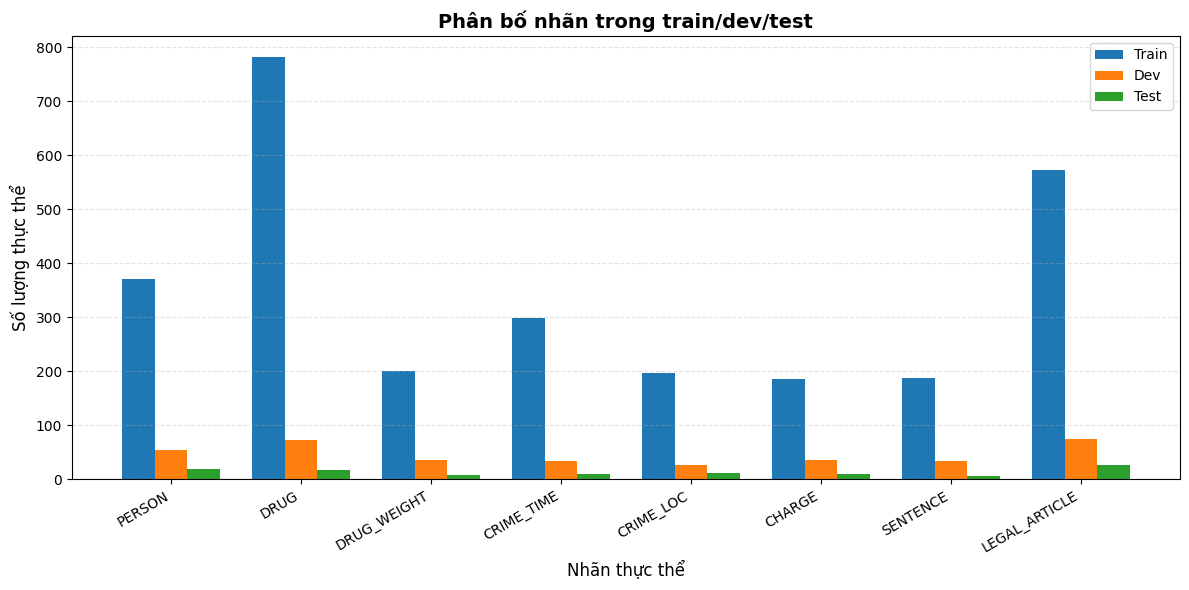

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = split_label_stats_df.copy()

labels = plot_df["Nhãn"].tolist()
train_counts = plot_df["Train"].tolist()
dev_counts = plot_df["Dev"].tolist()
test_counts = plot_df["Test"].tolist()

x = np.arange(len(labels))
bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - bar_width, train_counts, bar_width, label="Train")
plt.bar(x, dev_counts, bar_width, label="Dev")
plt.bar(x + bar_width, test_counts, bar_width, label="Test")

plt.xlabel("Nhãn thực thể", fontsize=12)
plt.ylabel("Số lượng thực thể", fontsize=12)
plt.title("Phân bố nhãn trong train/dev/test", fontsize=14, fontweight="bold")

plt.xticks(x, labels, rotation=30, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

## 3.7. Nhận xét về cách chia dữ liệu

Dữ liệu được chia thành ba tập train, dev và test theo một bộ split cố định. Bộ split này được sử dụng chung cho cả ba mô hình PhoBERT, XLM-RoBERTa và spaCy nhằm đảm bảo tính công bằng khi so sánh kết quả thực nghiệm.

Việc chia dữ liệu được thực hiện theo cấp độ bản án thay vì chia ngẫu nhiên từng câu hoặc từng đoạn. Cách chia này giúp hạn chế hiện tượng rò rỉ dữ liệu, tránh trường hợp các đoạn văn bản thuộc cùng một bản án xuất hiện đồng thời ở cả tập huấn luyện và tập kiểm thử.

Tập train được sử dụng để huấn luyện mô hình, tập dev được sử dụng để theo dõi kết quả trong quá trình huấn luyện và lựa chọn mô hình tốt nhất, còn tập test chỉ được sử dụng ở bước đánh giá cuối cùng.

# 4. Cấu hình thực nghiệm

## 4.1. Mục tiêu thực nghiệm

Mục tiêu của phần thực nghiệm là đánh giá hiệu quả của ba mô hình PhoBERT, XLM-RoBERTa và spaCy trong bài toán nhận diện thực thể có tên trên bản án hình sự về ma túy.

Cả ba mô hình được huấn luyện và đánh giá trên cùng một bộ dữ liệu train/dev/test nhằm đảm bảo tính công bằng khi so sánh kết quả. Tập train được dùng để huấn luyện mô hình, tập dev được dùng để theo dõi quá trình huấn luyện và lựa chọn mô hình tốt nhất, còn tập test được dùng để đánh giá kết quả cuối cùng.

## 4.2. Các mô hình được sử dụng

Trong đề tài này, ba mô hình được sử dụng để thực nghiệm gồm:

- PhoBERT: mô hình ngôn ngữ tiền huấn luyện cho tiếng Việt, được fine-tune cho bài toán token classification.
- XLM-RoBERTa-base: mô hình đa ngôn ngữ dựa trên kiến trúc RoBERTa, được fine-tune cho bài toán token classification.
- spaCy NER: mô hình NER truyền thống của thư viện spaCy, được huấn luyện trực tiếp trên dữ liệu gán nhãn theo character span.

Việc lựa chọn ba mô hình này giúp so sánh giữa mô hình transformer đơn ngữ tiếng Việt, mô hình transformer đa ngôn ngữ và mô hình NER truyền thống.

In [ ]:
import pandas as pd

model_description = pd.DataFrame([
    {
        "Mô hình": "PhoBERT",
        "Tên model": "vinai/phobert-base-v2",
        "Loại mô hình": "Transformer đơn ngữ tiếng Việt",
        "Cách huấn luyện": "Token classification",
    },
    {
        "Mô hình": "XLM-RoBERTa",
        "Tên model": "xlm-roberta-base",
        "Loại mô hình": "Transformer đa ngôn ngữ",
        "Cách huấn luyện": "Token classification",
    },
    {
        "Mô hình": "spaCy",
        "Tên model": "blank vi / xx",
        "Loại mô hình": "spaCy NER",
        "Cách huấn luyện": "Entity span classification",
    },
])

model_description

,Mô hình,Tên model,Loại mô hình,Cách huấn luyện
0,PhoBERT,vinai/phobert-base-v2,Transformer đơn ngữ tiếng Việt,Token classification
1,XLM-RoBERTa,xlm-roberta-base,Transformer đa ngôn ngữ,Token classification
2,spaCy,blank vi / xx,spaCy NER,Entity span classification


## 4.3. Cấu hình huấn luyện PhoBERT

PhoBERT được sử dụng làm mô hình transformer chính cho tiếng Việt. Dữ liệu gán nhãn được chuyển sang định dạng BIO và đưa vào mô hình dưới dạng bài toán token classification. Trong quá trình huấn luyện, mô hình sử dụng tập dev để theo dõi F1-score và lưu lại phiên bản có kết quả tốt nhất.

In [ ]:
phobert_config = pd.DataFrame([
    {"Tham số": "Base model", "Giá trị": "vinai/phobert-base-v2"},
    {"Tham số": "Max length", "Giá trị": 256},
    {"Tham số": "Epochs", "Giá trị": 40},
    {"Tham số": "Batch size", "Giá trị": 4},
    {"Tham số": "Learning rate", "Giá trị": "3e-5"},
    {"Tham số": "Weight decay", "Giá trị": 0.01},
    {"Tham số": "Warmup ratio", "Giá trị": 0.1},
    {"Tham số": "Early stopping", "Giá trị": 8},
    {"Tham số": "Seed", "Giá trị": 42},
    {"Tham số": "Loss function", "Giá trị": "Weighted CrossEntropyLoss"},
])

phobert_config

,Tham số,Giá trị
0,Base model,vinai/phobert-base-v2
1,Max length,256
2,Epochs,40
3,Batch size,4
4,Learning rate,3e-5
5,Weight decay,0.01
6,Warmup ratio,0.1
7,Early stopping,8
8,Seed,42
9,Loss function,Weighted CrossEntropyLoss


In [ ]:
!python train_phobert_shared.py \
  --data ../data/annotated/drug.jsonl \
  --output ../models/phobert-ner-weighted \
  --train-file ../data/splits/shared/train.jsonl \
  --dev-file ../data/splits/shared/dev.jsonl \
  --test-file ../data/splits/shared/test.jsonl \
  --epochs 40 \
  --batch 4 \
  --lr 3e-5

Device: cuda

[1/6] Load data: ../data/annotated/drug.jsonl
Records: 2673
BIO debug -> ../models/phobert-ner-weighted/drug_ner_debug.conll

Label distribution word-level:
  O                 : 106842
  B-PERSON          : 440
  I-PERSON          : 881
  B-DRUG            : 868
  I-DRUG            : 544
  B-CRIME_TIME      : 341
  I-CRIME_TIME      : 1268
  B-CRIME_LOC       : 235
  I-CRIME_LOC       : 2371
  B-DRUG_WEIGHT     : 244
  I-DRUG_WEIGHT     : 231
  B-CHARGE          : 229
  I-CHARGE          : 1498
  B-SENTENCE        : 228
  I-SENTENCE        : 910
  B-LEGAL_ARTICLE   : 674
  I-LEGAL_ARTICLE   : 2529

[2/6] Split data
Dùng shared split có sẵn:
  Train: ../data/splits/shared/train.jsonl
  Dev  : ../data/splits/shared/dev.jsonl
  Test : ../data/splits/shared/test.jsonl
Train records: 2303 | Dev records: 264 | Test records: 106

[3/6] Load tokenizer/model: vinai/phobert-base-v2
config.json: 100% 678/678 [00:00<00:00, 3.92MB/s]
vocab.txt: 100% 895k/895k [00:00<00:00, 12.7MB/s]


## 4.4. Cấu hình huấn luyện XLM-RoBERTa

XLM-RoBERTa-base được sử dụng để so sánh với PhoBERT. Đây là mô hình transformer đa ngôn ngữ, có khả năng xử lý nhiều ngôn ngữ khác nhau, trong đó có tiếng Việt. Tương tự PhoBERT, mô hình được fine-tune theo hướng token classification trên cùng bộ train/dev/test.

In [ ]:
xlmr_config = pd.DataFrame([
    {"Tham số": "Base model", "Giá trị": "xlm-roberta-base"},
    {"Tham số": "Max length", "Giá trị": 256},
    {"Tham số": "Epochs", "Giá trị": 40},
    {"Tham số": "Batch size", "Giá trị": 4},
    {"Tham số": "Learning rate", "Giá trị": "2e-5"},
    {"Tham số": "Weight decay", "Giá trị": 0.01},
    {"Tham số": "Warmup ratio", "Giá trị": 0.1},
    {"Tham số": "Early stopping", "Giá trị": 8},
    {"Tham số": "Seed", "Giá trị": 42},
    {"Tham số": "Loss function", "Giá trị": "Weighted CrossEntropyLoss"},
])

xlmr_config

,Tham số,Giá trị
0,Base model,xlm-roberta-base
1,Max length,256
2,Epochs,40
3,Batch size,4
4,Learning rate,2e-5
5,Weight decay,0.01
6,Warmup ratio,0.1
7,Early stopping,8
8,Seed,42
9,Loss function,Weighted CrossEntropyLoss


In [ ]:
!python train_xlmr_shared.py \
  --data ../data/annotated/drug.jsonl \
  --output ../models/xlmr-ner-weighted \
  --train-file ../data/splits/shared/train.jsonl \
  --dev-file ../data/splits/shared/dev.jsonl \
  --test-file ../data/splits/shared/test.jsonl \
  --epochs 40 \
  --batch 4 \
  --lr 2e-5

Device: cuda

[1/6] Load data: ../data/annotated/drug.jsonl
Records: 2673
BIO debug -> ../models/xlmr-ner-weighted/drug_ner_debug.conll

Label distribution word-level:
  O                 : 106842
  B-PERSON          : 440
  I-PERSON          : 881
  B-DRUG            : 868
  I-DRUG            : 544
  B-CRIME_TIME      : 341
  I-CRIME_TIME      : 1268
  B-CRIME_LOC       : 235
  I-CRIME_LOC       : 2371
  B-DRUG_WEIGHT     : 244
  I-DRUG_WEIGHT     : 231
  B-CHARGE          : 229
  I-CHARGE          : 1498
  B-SENTENCE        : 228
  I-SENTENCE        : 910
  B-LEGAL_ARTICLE   : 674
  I-LEGAL_ARTICLE   : 2529

[2/6] Split data
Dùng shared split có sẵn:
  Train: ../data/splits/shared/train.jsonl
  Dev  : ../data/splits/shared/dev.jsonl
  Test : ../data/splits/shared/test.jsonl
Train records: 2303 | Dev records: 264 | Test records: 106

[3/6] Load tokenizer/model: xlm-roberta-base
Loading weights: 100% 197/197 [00:00<00:00, 754.63it/s]
[transformers] XLMRobertaForTokenClassification LOAD

## 4.5. Cấu hình huấn luyện spaCy

Mô hình spaCy NER được sử dụng như một mô hình so sánh với hai mô hình transformer. Khác với PhoBERT và XLM-RoBERTa, spaCy được huấn luyện dựa trên các span thực thể theo vị trí ký tự trong văn bản. Kết quả của spaCy được đánh giá theo entity-level exact match, tức là một thực thể được xem là đúng khi đồng thời đúng vị trí bắt đầu, vị trí kết thúc và loại nhãn.

In [ ]:
spacy_config = pd.DataFrame([
    {"Tham số": "Base model", "Giá trị": "spaCy blank vi / xx"},
    {"Tham số": "Epochs", "Giá trị": 40},
    {"Tham số": "Dropout", "Giá trị": 0.25},
    {"Tham số": "Batch start", "Giá trị": 4.0},
    {"Tham số": "Batch stop", "Giá trị": 32.0},
    {"Tham số": "Batch compound", "Giá trị": 1.001},
    {"Tham số": "Seed", "Giá trị": 42},
    {"Tham số": "Evaluation", "Giá trị": "Entity-level exact match"},
])

spacy_config

,Tham số,Giá trị
0,Base model,spaCy blank vi / xx
1,Epochs,40
2,Dropout,0.25
3,Batch start,4.0
4,Batch stop,32.0
5,Batch compound,1.001
6,Seed,42
7,Evaluation,Entity-level exact match


In [ ]:
!python train_spacy_shared.py \
  --input ../data/annotated/drug.jsonl \
  --out_dir ../models/spacy-ner-drug \
  --train-file ../data/splits/shared/train.jsonl \
  --dev-file ../data/splits/shared/dev.jsonl \
  --test-file ../data/splits/shared/test.jsonl \
  --epochs 40

Device/model: spaCy CPU/GPU tùy runtime
Input: ../data/annotated/drug.jsonl
Output: ../models/spacy-ner-drug
Records: 2673

Dùng shared split có sẵn:
Train: ../data/splits/shared/train.jsonl
Dev  : ../data/splits/shared/dev.jsonl
Test : ../data/splits/shared/test.jsonl

Split data by document/source
Train records: 2303
Dev records  : 264
Test records : 106

Split statistics:
            Entity type  Training  Validation  Testing  All
                 PERSON       371          50       19  440
                   DRUG       778          72       18  868
            DRUG_WEIGHT       200          36        8  244
             CRIME_TIME       298          33       10  341
              CRIME_LOC       197          27       11  235
                 CHARGE       185          35        9  229
               SENTENCE       187          34        7  228
          LEGAL_ARTICLE       573          74       27  674
     #Entities in total      2789         361      109 3259
#Rows/snippets in tota

## 4.6. Thước đo đánh giá

Để đánh giá hiệu quả của các mô hình, đề tài sử dụng ba thước đo chính gồm Precision, Recall và F1-score.

Precision thể hiện tỷ lệ thực thể dự đoán đúng trên tổng số thực thể mà mô hình dự đoán. Recall thể hiện tỷ lệ thực thể dự đoán đúng trên tổng số thực thể thực tế trong dữ liệu. F1-score là trung bình điều hòa giữa Precision và Recall, thường được sử dụng để đánh giá tổng quát hiệu quả của mô hình NER.

Một dự đoán được xem là đúng khi mô hình nhận diện đúng cả ranh giới thực thể và loại nhãn tương ứng.

In [ ]:
metric_description = pd.DataFrame([
    {
        "Thước đo": "Precision",
        "Ý nghĩa": "Tỷ lệ thực thể dự đoán đúng trên tổng số thực thể được mô hình dự đoán",
        "Công thức": "TP / (TP + FP)",
    },
    {
        "Thước đo": "Recall",
        "Ý nghĩa": "Tỷ lệ thực thể dự đoán đúng trên tổng số thực thể thực tế",
        "Công thức": "TP / (TP + FN)",
    },
    {
        "Thước đo": "F1-score",
        "Ý nghĩa": "Trung bình điều hòa giữa Precision và Recall",
        "Công thức": "2 * Precision * Recall / (Precision + Recall)",
    },
])

metric_description

,Thước đo,Ý nghĩa,Công thức
0,Precision,Tỷ lệ thực thể dự đoán đúng trên tổng số thực ...,TP / (TP + FP)
1,Recall,Tỷ lệ thực thể dự đoán đúng trên tổng số thực ...,TP / (TP + FN)
2,F1-score,Trung bình điều hòa giữa Precision và Recall,2 * Precision * Recall / (Precision + Recall)


Trong đó:

- TP là số thực thể được dự đoán đúng.
- FP là số thực thể mô hình dự đoán nhưng không đúng với nhãn thực tế.
- FN là số thực thể có trong dữ liệu thực tế nhưng mô hình bỏ sót.

Trong bài toán NER, F1-score thường được xem là chỉ số quan trọng nhất vì nó cân bằng giữa khả năng dự đoán chính xác và khả năng phát hiện đầy đủ thực thể.

## 4.7. Bảng tổng hợp cấu hình thực nghiệm

In [ ]:
experiment_config = pd.DataFrame([
    {
        "Mô hình": "PhoBERT",
        "Base model": "vinai/phobert-base-v2",
        "Epochs": 40,
        "Batch size": 4,
        "Max length": 256,
        "Learning rate": "3e-5",
        "Early stopping": 8,
    },
    {
        "Mô hình": "XLM-RoBERTa",
        "Base model": "xlm-roberta-base",
        "Epochs": 40,
        "Batch size": 4,
        "Max length": 256,
        "Learning rate": "2e-5",
        "Early stopping": 8,
    },
    {
        "Mô hình": "spaCy",
        "Base model": "blank vi / xx",
        "Epochs": 40,
        "Batch size": "4.0 -> 32.0",
        "Max length": "-",
        "Learning rate": "-",
        "Early stopping": "-",
    },
])

experiment_config.style.set_properties(**{
    "text-align": "center",
    "font-size": "14px",
    "padding": "6px",
})

,Mô hình,Base model,Epochs,Batch size,Max length,Learning rate,Early stopping
0,PhoBERT,vinai/phobert-base-v2,40,4,256,3e-5,8
1,XLM-RoBERTa,xlm-roberta-base,40,4,256,2e-5,8
2,spaCy,blank vi / xx,40,4.0 -> 32.0,-,-,-


## 4.8. Nhận xét về cấu hình thực nghiệm

Trong thực nghiệm, PhoBERT và XLM-RoBERTa được huấn luyện theo cùng hướng tiếp cận token classification, sử dụng định dạng BIO và hàm mất mát Weighted CrossEntropyLoss nhằm hạn chế ảnh hưởng của hiện tượng mất cân bằng nhãn.

spaCy được sử dụng như một mô hình so sánh truyền thống, huấn luyện trực tiếp trên các span thực thể theo vị trí ký tự. Do khác biệt về kiến trúc và cách biểu diễn dữ liệu, kết quả của spaCy được dùng để so sánh xu hướng tổng quát với hai mô hình transformer.

Cả ba mô hình đều sử dụng cùng bộ train/dev/test đã được tạo trước đó. Điều này giúp đảm bảo rằng sự khác biệt về kết quả đánh giá đến từ khả năng học của mô hình, thay vì do khác biệt trong cách chia dữ liệu.

# 5. Kết quả thực nghiệm tổng thể

## 5.1. Đọc kết quả đánh giá của các mô hình

Sau khi huấn luyện, kết quả đánh giá của từng mô hình trên tập test được lưu dưới dạng file `test_results.json`. Ở bước này, tiến hành đọc kết quả của ba mô hình PhoBERT, XLM-RoBERTa và spaCy để phục vụ so sánh tổng thể.

In [ ]:
import json
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NER_NLP_3")

PHOBERT_DIR = BASE_DIR / "models/phobert-ner-weighted"
SPACY_DIR = BASE_DIR / "models/spacy-ner-drug"
XLMR_DIR = BASE_DIR / "models/xlmr-ner-weighted"

MODEL_DIRS = {
    "PhoBERT": PHOBERT_DIR,
    "spaCy": SPACY_DIR,
    "XLM-RoBERTa": XLMR_DIR,
}


def load_test_results(model_dir):
    json_path = model_dir / "test_results.json"

    if not json_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


results = {}

for model_name, model_dir in MODEL_DIRS.items():
    results[model_name] = load_test_results(model_dir)

print("Đã đọc kết quả của các mô hình:")
for model_name in results:
    print("-", model_name)

Đã đọc kết quả của các mô hình:
- PhoBERT
- spaCy
- XLM-RoBERTa


## 5.2. Tạo bảng so sánh Precision, Recall, F1 tổng thể

In [ ]:
overall_rows = []

for model_name, result in results.items():
    overall = result.get("overall", {})

    overall_rows.append({
        "Mô hình": model_name,
        "Precision": overall.get("precision", 0.0),
        "Recall": overall.get("recall", 0.0),
        "F1-score": overall.get("f1", 0.0),
    })

overall_df = pd.DataFrame(overall_rows)

overall_df = overall_df.sort_values("F1-score", ascending=False).reset_index(drop=True)

overall_df.style.format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
}).set_properties(**{
    "text-align": "center",
    "font-size": "14px",
    "padding": "6px",
}).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("font-size", "14px"),
            ("background-color", "#f2f2f2"),
            ("font-weight", "bold"),
        ],
    }
])

,Mô hình,Precision,Recall,F1-score
0,PhoBERT,0.8559,0.8716,0.8636
1,XLM-RoBERTa,0.8750,0.8349,0.8545
2,spaCy,0.7736,0.7523,0.7628


## 5.3. Biểu đồ so sánh F1 tổng thể

Biểu đồ dưới đây thể hiện F1-score tổng thể của ba mô hình. Qua đó có thể quan sát trực quan mô hình nào đạt hiệu quả cao hơn trên tập test chung.

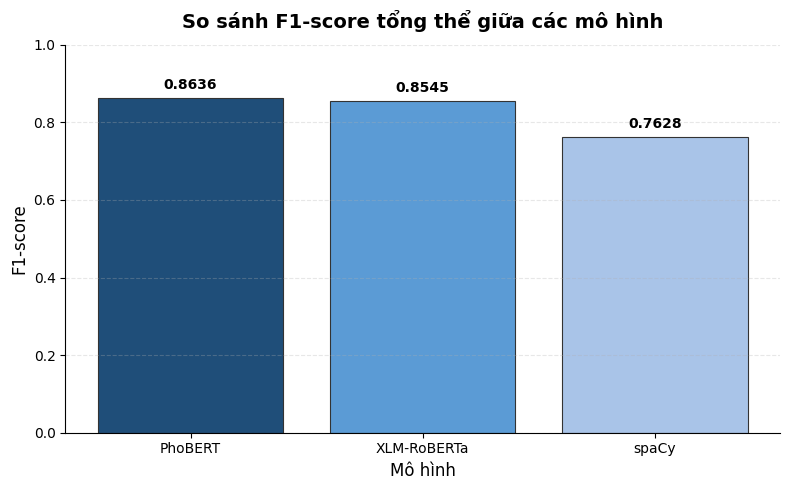

In [ ]:
import matplotlib.pyplot as plt

plot_df = overall_df.copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_df["Mô hình"],
    plot_df["F1-score"],
    color=["#1F4E79", "#5B9BD5", "#A9C4E8"],
    edgecolor="#333333",
    linewidth=0.8
)

plt.xlabel("Mô hình", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.title(
    "So sánh F1-score tổng thể giữa các mô hình",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 5.4. Lưu bảng kết quả tổng thể


In [ ]:
OUTPUT_DIR = BASE_DIR / "models/statistics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

overall_output_path = OUTPUT_DIR / "overall_model_comparison.csv"
overall_df.to_csv(overall_output_path, index=False, encoding="utf-8-sig")

print("Đã lưu bảng kết quả tổng thể tại:")
print(overall_output_path)

Đã lưu bảng kết quả tổng thể tại:
/content/drive/MyDrive/NER_NLP_3/models/statistics/overall_model_comparison.csv


## 5.5. Nhận xét kết quả tổng thể

Trên tập test chung, PhoBERT đạt F1-score tổng thể cao nhất với 0.8636, tiếp theo là XLM-RoBERTa với 0.8545 và spaCy với 0.7628. Kết quả này cho thấy PhoBERT có hiệu quả tổng thể nhỉnh hơn so với hai mô hình còn lại.

Tuy nhiên, khoảng cách giữa PhoBERT và XLM-RoBERTa không lớn. Điều này cho thấy XLM-RoBERTa vẫn là mô hình có khả năng cạnh tranh tốt trong bài toán nhận diện thực thể trên bản án hình sự về ma túy. Trong khi đó, spaCy có kết quả thấp hơn rõ rệt, cho thấy mô hình NER truyền thống gặp nhiều hạn chế hơn khi xử lý văn bản pháp lý có cấu trúc dài và phức tạp.

Do kết quả tổng thể có thể bị ảnh hưởng bởi số lượng thực thể của từng nhãn, cần tiếp tục phân tích F1-score theo từng nhãn để đánh giá chi tiết hơn điểm mạnh và điểm yếu của từng mô hình.

# 6. So sánh kết quả theo từng nhãn

## 6.1. Đọc kết quả F1-score theo từng nhãn

In [ ]:
import json
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NER_NLP_3")

PHOBERT_DIR = BASE_DIR / "models/phobert-ner-weighted"
SPACY_DIR = BASE_DIR / "models/spacy-ner-drug"
XLMR_DIR = BASE_DIR / "models/xlmr-ner-weighted"

LABEL_ORDER = [
    "PERSON",
    "DRUG",
    "DRUG_WEIGHT",
    "CRIME_TIME",
    "CRIME_LOC",
    "CHARGE",
    "SENTENCE",
    "LEGAL_ARTICLE",
    "OVERALL",
]


def load_result_table(model_name, model_dir):
    csv_path = model_dir / "test_results_table.csv"
    json_path = model_dir / "test_results.json"

    if csv_path.exists():
        df = pd.read_csv(csv_path)

        if "Nhãn" not in df.columns:
            if "label" in df.columns:
                df = df.rename(columns={"label": "Nhãn"})
            elif "Entity type" in df.columns:
                df = df.rename(columns={"Entity type": "Nhãn"})

        return df

    if not json_path.exists():
        raise FileNotFoundError(f"Không tìm thấy kết quả của {model_name}: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        results = json.load(f)

    rows = []

    for label in LABEL_ORDER:
        key = "overall" if label == "OVERALL" else label

        if key not in results:
            rows.append({
                "Nhãn": label,
                "Precision": 0.0,
                "Recall": 0.0,
                "F1": 0.0,
            })
            continue

        score = results[key]

        rows.append({
            "Nhãn": label,
            "Precision": score.get("precision", 0.0),
            "Recall": score.get("recall", 0.0),
            "F1": score.get("f1", 0.0),
        })

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    return df


df_phobert = load_result_table("PhoBERT", PHOBERT_DIR)
df_spacy = load_result_table("spaCy", SPACY_DIR)
df_xlmr = load_result_table("XLM-RoBERTa", XLMR_DIR)

print("Đã đọc kết quả theo nhãn của 3 mô hình.")

Đã đọc kết quả theo nhãn của 3 mô hình.


## 6.2. Tạo bảng so sánh F1-score theo nhãn

In [ ]:
def get_f1(df, label):
    row = df[df["Nhãn"] == label]

    if row.empty:
        return 0.0

    return float(row.iloc[0]["F1"])


def get_best_model(scores):
    max_score = max(scores.values())
    winners = [name for name, score in scores.items() if score == max_score]

    if len(winners) == 1:
        return winners[0]

    return "Bằng nhau: " + ", ".join(winners)


rows = []

for label in LABEL_ORDER:
    phobert_f1 = get_f1(df_phobert, label)
    spacy_f1 = get_f1(df_spacy, label)
    xlmr_f1 = get_f1(df_xlmr, label)

    scores = {
        "PhoBERT": phobert_f1,
        "spaCy": spacy_f1,
        "XLM-RoBERTa": xlmr_f1,
    }

    rows.append({
        "Nhãn": label,
        "PhoBERT": phobert_f1,
        "spaCy": spacy_f1,
        "XLM-RoBERTa": xlmr_f1,
        "Model tốt nhất": get_best_model(scores),
    })

compare_df = pd.DataFrame(rows)

compare_df.style.format({
    "PhoBERT": "{:.4f}",
    "spaCy": "{:.4f}",
    "XLM-RoBERTa": "{:.4f}",
}).set_properties(**{
    "text-align": "center",
    "font-size": "14px",
    "padding": "6px",
}).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("font-size", "14px"),
            ("background-color", "#f2f2f2"),
            ("font-weight", "bold"),
        ],
    }
])

,Nhãn,PhoBERT,spaCy,XLM-RoBERTa,Model tốt nhất
0,PERSON,0.8125,0.7273,0.8125,"Bằng nhau: PhoBERT, XLM-RoBERTa"
1,DRUG,0.9000,0.8889,0.9189,XLM-RoBERTa
2,DRUG_WEIGHT,0.8889,0.8889,0.8889,"Bằng nhau: PhoBERT, XLM-RoBERTa"
3,CRIME_TIME,0.7619,0.6400,0.8000,XLM-RoBERTa
4,CRIME_LOC,0.8000,0.3333,0.6400,PhoBERT
5,CHARGE,0.9412,0.7368,0.9412,"Bằng nhau: PhoBERT, XLM-RoBERTa"
6,SENTENCE,1.0000,0.7273,1.0000,"Bằng nhau: PhoBERT, XLM-RoBERTa"
7,LEGAL_ARTICLE,0.8679,0.8727,0.8800,XLM-RoBERTa
8,OVERALL,0.8636,0.7628,0.8545,PhoBERT


## 6.3. Lưu bảng so sánh F1-score theo nhãn

In [ ]:
OUTPUT_DIR = BASE_DIR / "models/statistics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

compare_output_path = OUTPUT_DIR / "f1_by_label_comparison.csv"
compare_df.to_csv(compare_output_path, index=False, encoding="utf-8-sig")

print("Đã lưu bảng so sánh F1-score theo nhãn tại:")
print(compare_output_path)

Đã lưu bảng so sánh F1-score theo nhãn tại:
/content/drive/MyDrive/NER_NLP_3/models/statistics/f1_by_label_comparison.csv


## 6.4. Biểu đồ so sánh F1-score theo từng nhãn

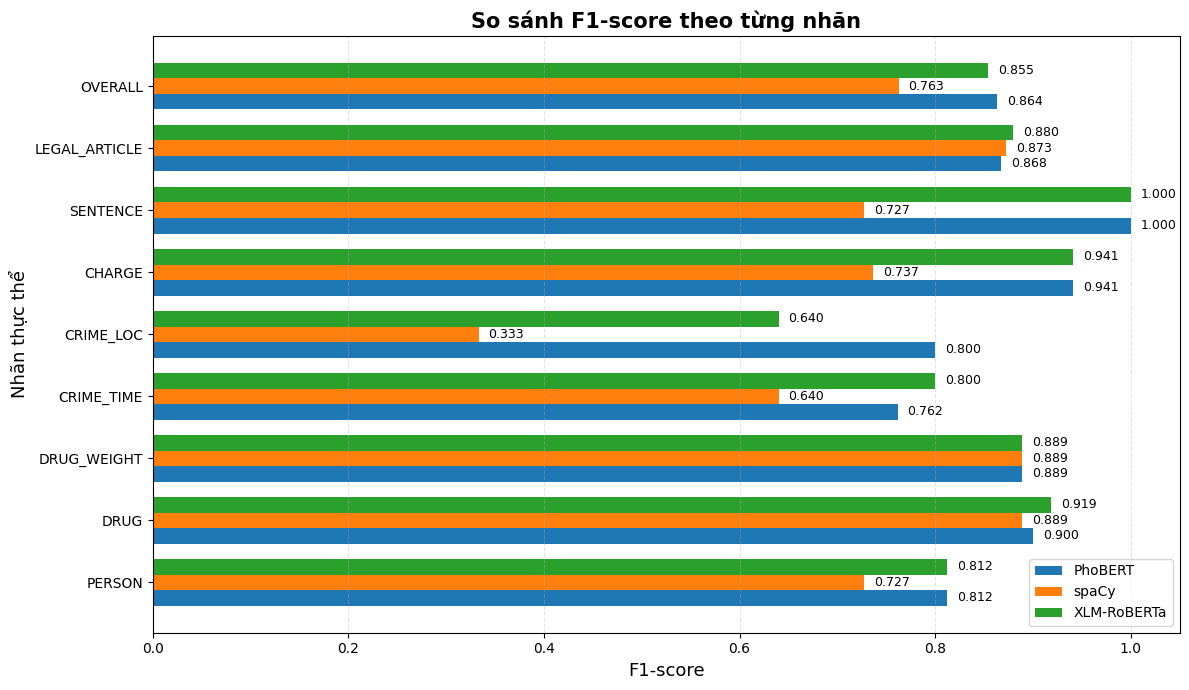

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = compare_df.copy()

labels = plot_df["Nhãn"].tolist()
phobert_scores = plot_df["PhoBERT"].tolist()
spacy_scores = plot_df["spaCy"].tolist()
xlmr_scores = plot_df["XLM-RoBERTa"].tolist()

y = np.arange(len(labels))
bar_height = 0.25

plt.figure(figsize=(12, 7))

plt.barh(y - bar_height, phobert_scores, bar_height, label="PhoBERT")
plt.barh(y, spacy_scores, bar_height, label="spaCy")
plt.barh(y + bar_height, xlmr_scores, bar_height, label="XLM-RoBERTa")

plt.xlabel("F1-score", fontsize=13)
plt.ylabel("Nhãn thực thể", fontsize=13)
plt.title("So sánh F1-score theo từng nhãn", fontsize=15, fontweight="bold")

plt.yticks(y, labels)
plt.xlim(0, 1.05)
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.35)

for i, v in enumerate(phobert_scores):
    plt.text(min(v + 0.01, 1.01), i - bar_height, f"{v:.3f}", va="center", fontsize=9)

for i, v in enumerate(spacy_scores):
    plt.text(min(v + 0.01, 1.01), i, f"{v:.3f}", va="center", fontsize=9)

for i, v in enumerate(xlmr_scores):
    plt.text(min(v + 0.01, 1.01), i + bar_height, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 6.5. Nhận xét kết quả theo từng nhãn

Từ bảng kết quả, có thể thấy PhoBERT đạt F1-score tổng thể cao nhất với 0.8636, tiếp theo là XLM-RoBERTa với 0.8545 và spaCy với 0.7628. Tuy nhiên, khi xét theo từng nhãn, XLM-RoBERTa lại đạt kết quả tốt hơn ở một số nhãn như DRUG, CRIME_TIME và LEGAL_ARTICLE.

PhoBERT đạt kết quả tốt nhất ở nhãn CRIME_LOC và có kết quả ngang bằng với XLM-RoBERTa ở các nhãn PERSON, DRUG_WEIGHT, CHARGE và SENTENCE. Điều này cho thấy PhoBERT có hiệu quả ổn định trên nhiều loại thực thể và đạt kết quả tổng thể tốt nhất trên tập test chung.

spaCy có kết quả thấp hơn hai mô hình transformer ở hầu hết các nhãn, đặc biệt ở CRIME_LOC, CRIME_TIME, CHARGE và SENTENCE. Nguyên nhân có thể đến từ việc spaCy không khai thác ngữ cảnh sâu như các mô hình transformer, trong khi văn bản bản án hình sự thường có câu dài, nhiều cụm pháp lý và thực thể có ranh giới phức tạp.

Nhìn chung, PhoBERT là mô hình có hiệu quả tổng thể tốt nhất trong thực nghiệm, nhưng XLM-RoBERTa có kết quả rất cạnh tranh và vượt PhoBERT ở một số nhãn riêng lẻ.

# 7. Phân tích lỗi và thảo luận kết quả

## 7.1. Mục tiêu phân tích lỗi

Sau khi so sánh kết quả tổng thể và kết quả theo từng nhãn, phần này tập trung phân tích nguyên nhân dẫn đến sự khác biệt giữa các mô hình. Việc phân tích lỗi giúp xác định những loại thực thể dễ nhận diện, những loại thực thể khó nhận diện và các nguyên nhân khiến mô hình dự đoán sai.

Đối với bài toán nhận diện thực thể trong bản án hình sự về ma túy, một dự đoán sai thường xuất phát từ hai nhóm lỗi chính: sai loại nhãn và sai ranh giới thực thể. Trong đó, sai ranh giới thực thể thường xuất hiện ở các nhãn có độ dài lớn như CRIME_LOC, SENTENCE hoặc LEGAL_ARTICLE.

## 7.2. Các nhãn có kết quả tốt

Một số nhãn đạt F1-score cao hơn so với các nhãn còn lại do có cấu trúc biểu hiện rõ ràng trong văn bản bản án. Các nhãn như DRUG, DRUG_WEIGHT, CHARGE và SENTENCE thường có đặc điểm nhận diện tương đối ổn định.

Nhãn DRUG thường là tên các loại ma túy cụ thể như Methamphetamine, Heroine, Ketamine hoặc cần sa. Đây là các từ khóa có tính nhận diện cao nên mô hình dễ học được đặc trưng.

Nhãn DRUG_WEIGHT thường đi kèm với các đơn vị đo khối lượng như gam, gram, g, kg hoặc mg. Do đó, cấu trúc của nhãn này khá ổn định và ít phụ thuộc vào ngữ cảnh dài.

Nhãn CHARGE và SENTENCE thường xuất hiện ở phần quyết định của bản án, nơi có cách diễn đạt tương đối khuôn mẫu. Điều này giúp mô hình dễ nhận diện hơn so với các nhãn nằm rải rác trong nhiều phần khác nhau của văn bản.

In [ ]:
high_score_df = compare_df[
    (compare_df["Nhãn"] != "OVERALL") &
    (
        (compare_df["PhoBERT"] >= 0.85) |
        (compare_df["spaCy"] >= 0.85) |
        (compare_df["XLM-RoBERTa"] >= 0.85)
    )
].copy()

high_score_df

,Nhãn,PhoBERT,spaCy,XLM-RoBERTa,Model tốt nhất
1,DRUG,0.9000,0.888889,0.9189,XLM-RoBERTa
2,DRUG_WEIGHT,0.8889,0.888889,0.8889,"Bằng nhau: PhoBERT, XLM-RoBERTa"
5,CHARGE,0.9412,0.736842,0.9412,"Bằng nhau: PhoBERT, XLM-RoBERTa"
6,SENTENCE,1.0000,0.727273,1.0000,"Bằng nhau: PhoBERT, XLM-RoBERTa"
7,LEGAL_ARTICLE,0.8679,0.872727,0.8800,XLM-RoBERTa


## 7.3. Các nhãn có kết quả thấp hơn

Một số nhãn có kết quả thấp hơn do phụ thuộc nhiều vào ngữ cảnh và có ranh giới thực thể phức tạp. Trong bộ dữ liệu bản án hình sự về ma túy, các nhãn như CRIME_TIME và CRIME_LOC thường khó nhận diện hơn.

Nhãn CRIME_TIME có thể xuất hiện dưới nhiều dạng khác nhau như ngày, giờ, khoảng thời gian hoặc cụm thời gian gắn với diễn biến hành vi phạm tội. Một số biểu thức thời gian còn phụ thuộc vào câu trước đó, làm tăng độ khó cho mô hình.

Nhãn CRIME_LOC thường là các cụm địa chỉ dài, bao gồm nhiều thành phần như số nhà, tên đường, thôn, xã, huyện, tỉnh hoặc tên quán, khách sạn, khu vực. Vì vậy, mô hình dễ gặp lỗi thiếu hoặc thừa một phần ranh giới địa điểm.

Ngoài ra, LEGAL_ARTICLE cũng có thể gây nhầm lẫn do văn bản pháp lý thường chứa nhiều loại điều luật khác nhau. Không phải điều luật nào xuất hiện trong bản án cũng thuộc phạm vi cần gán nhãn, nên mô hình cần học được ngữ cảnh áp dụng của từng điều luật.

In [ ]:
low_score_df = compare_df[
    (compare_df["Nhãn"] != "OVERALL") &
    (
        (compare_df["PhoBERT"] < 0.80) |
        (compare_df["spaCy"] < 0.80) |
        (compare_df["XLM-RoBERTa"] < 0.80)
    )
].copy()

low_score_df

,Nhãn,PhoBERT,spaCy,XLM-RoBERTa,Model tốt nhất
0,PERSON,0.8125,0.727273,0.8125,"Bằng nhau: PhoBERT, XLM-RoBERTa"
3,CRIME_TIME,0.7619,0.640000,0.8000,XLM-RoBERTa
4,CRIME_LOC,0.8000,0.333333,0.6400,PhoBERT
5,CHARGE,0.9412,0.736842,0.9412,"Bằng nhau: PhoBERT, XLM-RoBERTa"
6,SENTENCE,1.0000,0.727273,1.0000,"Bằng nhau: PhoBERT, XLM-RoBERTa"


## 7.4. So sánh lỗi giữa các mô hình

Kết quả thực nghiệm cho thấy hai mô hình transformer là PhoBERT và XLM-RoBERTa đạt hiệu quả cao hơn so với spaCy. Nguyên nhân là do các mô hình transformer có khả năng khai thác ngữ cảnh hai chiều tốt hơn, phù hợp với văn bản pháp lý có cấu trúc câu dài và nhiều thông tin phụ thuộc lẫn nhau.

spaCy có kết quả thấp hơn ở nhiều nhãn, đặc biệt là các nhãn yêu cầu hiểu ngữ cảnh hoặc có ranh giới dài. Điều này cho thấy mô hình NER truyền thống gặp hạn chế khi xử lý các thực thể phức tạp trong bản án.

Giữa PhoBERT và XLM-RoBERTa, kết quả khá sát nhau. PhoBERT đạt F1-score tổng thể cao hơn, trong khi XLM-RoBERTa đạt kết quả tốt hơn ở một số nhãn riêng lẻ. Điều này cho thấy PhoBERT có hiệu quả tổng thể ổn định hơn trên tập test, còn XLM-RoBERTa vẫn có khả năng nhận diện tốt đối với một số loại thực thể cụ thể.

In [ ]:
win_count = compare_df[compare_df["Nhãn"] != "OVERALL"]["Model tốt nhất"].value_counts().reset_index()
win_count.columns = ["Model tốt nhất", "Số nhãn"]

win_count

,Model tốt nhất,Số nhãn
0,"Bằng nhau: PhoBERT, XLM-RoBERTa",4
1,XLM-RoBERTa,3
2,PhoBERT,1


## 7.5. Một số lỗi thường gặp


In [ ]:
error_analysis_df = pd.DataFrame([
    {
        "Loại lỗi": "Sai ranh giới thực thể",
        "Nhãn thường gặp": "CRIME_LOC, SENTENCE, LEGAL_ARTICLE",
        "Mô tả": "Mô hình nhận diện thiếu hoặc thừa một phần của thực thể.",
        "Ví dụ": "Thiếu tên xã, huyện hoặc tỉnh trong cụm địa điểm phạm tội.",
    },
    {
        "Loại lỗi": "Bỏ sót thực thể",
        "Nhãn thường gặp": "CRIME_TIME, CRIME_LOC",
        "Mô tả": "Mô hình không nhận diện được thực thể có trong văn bản.",
        "Ví dụ": "Bỏ sót cụm thời gian nằm trong câu dài hoặc xa động từ chỉ hành vi phạm tội.",
    },
    {
        "Loại lỗi": "Nhầm loại nhãn",
        "Nhãn thường gặp": "LEGAL_ARTICLE, SENTENCE",
        "Mô tả": "Mô hình dự đoán đúng đoạn văn bản nhưng gán sai loại thực thể.",
        "Ví dụ": "Nhầm điều luật áp dụng hình phạt với điều luật về xử lý vật chứng.",
    },
    {
        "Loại lỗi": "Dự đoán thừa",
        "Nhãn thường gặp": "DRUG, LEGAL_ARTICLE",
        "Mô tả": "Mô hình nhận diện những cụm không thuộc phạm vi cần gán nhãn.",
        "Ví dụ": "Nhận diện tên chất ma túy trong phần test nước tiểu dù không liên quan trực tiếp đến vật chứng.",
    },
])

error_analysis_df

,Loại lỗi,Nhãn thường gặp,Mô tả,Ví dụ
0,Sai ranh giới thực thể,"CRIME_LOC, SENTENCE, LEGAL_ARTICLE",Mô hình nhận diện thiếu hoặc thừa một phần của...,"Thiếu tên xã, huyện hoặc tỉnh trong cụm địa đi..."
1,Bỏ sót thực thể,"CRIME_TIME, CRIME_LOC",Mô hình không nhận diện được thực thể có trong...,Bỏ sót cụm thời gian nằm trong câu dài hoặc xa...
2,Nhầm loại nhãn,"LEGAL_ARTICLE, SENTENCE",Mô hình dự đoán đúng đoạn văn bản nhưng gán sa...,Nhầm điều luật áp dụng hình phạt với điều luật...
3,Dự đoán thừa,"DRUG, LEGAL_ARTICLE",Mô hình nhận diện những cụm không thuộc phạm v...,Nhận diện tên chất ma túy trong phần test nước...


## 7.6. Nguyên nhân gây lỗi

Các lỗi dự đoán của mô hình có thể xuất phát từ nhiều nguyên nhân khác nhau.

Thứ nhất, văn bản bản án hình sự có nhiều câu dài và chứa nhiều thông tin pháp lý trong cùng một câu. Điều này khiến mô hình khó xác định chính xác ranh giới của thực thể.

Thứ hai, một số loại thực thể có biểu hiện không cố định. Ví dụ, CRIME_TIME có thể được diễn đạt bằng ngày tháng cụ thể, khoảng thời gian hoặc cụm từ mô tả thời điểm. CRIME_LOC cũng có thể là địa chỉ hành chính, tên quán, tên khách sạn hoặc một khu vực cụ thể.

Thứ ba, dữ liệu có hiện tượng mất cân bằng nhãn. Những nhãn có số lượng thực thể ít hơn thường khiến mô hình khó học được đặc trưng ổn định.

Thứ tư, một số thực thể trong văn bản pháp lý phụ thuộc vào quy tắc gán nhãn. Ví dụ, không phải mọi điều luật xuất hiện trong bản án đều được gán nhãn LEGAL_ARTICLE, mà chỉ những điều luật liên quan trực tiếp đến tội danh, hình phạt hoặc căn cứ pháp lý chính. Điều này làm bài toán khó hơn so với nhận diện từ khóa thông thường.

## 7.7. Bảng tổng hợp mức độ khó của từng nhãn


In [ ]:
difficulty_df = pd.DataFrame([
    {
        "Nhóm": "Dễ",
        "Nhãn": "DRUG, DRUG_WEIGHT",
        "Lý do": "Có từ khóa và đơn vị đo rõ ràng, cấu trúc biểu hiện ổn định.",
    },
    {
        "Nhóm": "Trung bình",
        "Nhãn": "PERSON, CHARGE, SENTENCE, LEGAL_ARTICLE",
        "Lý do": "Có cấu trúc tương đối khuôn mẫu nhưng vẫn có nhiều biến thể trong văn bản bản án.",
    },
    {
        "Nhóm": "Khó",
        "Nhãn": "CRIME_TIME, CRIME_LOC",
        "Lý do": "Phụ thuộc nhiều vào ngữ cảnh, ranh giới thực thể dài hoặc không ổn định.",
    },
])

difficulty_df

,Nhóm,Nhãn,Lý do
0,Dễ,"DRUG, DRUG_WEIGHT","Có từ khóa và đơn vị đo rõ ràng, cấu trúc biểu..."
1,Trung bình,"PERSON, CHARGE, SENTENCE, LEGAL_ARTICLE",Có cấu trúc tương đối khuôn mẫu nhưng vẫn có n...
2,Khó,"CRIME_TIME, CRIME_LOC","Phụ thuộc nhiều vào ngữ cảnh, ranh giới thực t..."


## 7.8. Nhận xét chung

Từ kết quả phân tích, có thể nhận thấy hiệu quả của mô hình phụ thuộc nhiều vào đặc điểm của từng loại thực thể. Những nhãn có cấu trúc rõ ràng như DRUG và DRUG_WEIGHT thường đạt kết quả cao hơn. Ngược lại, các nhãn phụ thuộc nhiều vào ngữ cảnh và có ranh giới dài như CRIME_TIME và CRIME_LOC thường khó nhận diện hơn.

Kết quả cũng cho thấy các mô hình transformer có ưu thế rõ rệt so với spaCy trong bài toán nhận diện thực thể trên bản án hình sự về ma túy. PhoBERT đạt kết quả tổng thể cao nhất, tuy nhiên XLM-RoBERTa có kết quả rất cạnh tranh và tốt hơn ở một số nhãn riêng lẻ.

Nhìn chung, kết quả thực nghiệm cho thấy việc sử dụng các mô hình transformer là phù hợp với bài toán NER trong văn bản pháp lý tiếng Việt. Tuy nhiên, cần tiếp tục cải thiện chất lượng dữ liệu, tăng số lượng mẫu cho các nhãn khó và xử lý tốt hơn các thực thể có ranh giới dài để nâng cao hiệu quả nhận diện.

# 8. Kết luận thực nghiệm

## 8.1. Tóm tắt quá trình thực nghiệm

Trong notebook này, dữ liệu bản án hình sự về ma túy sau khi được thu thập, tiền xử lý và gán nhãn đã được sử dụng để huấn luyện và đánh giá các mô hình nhận diện thực thể có tên. Bộ dữ liệu gồm 8 loại thực thể: PERSON, DRUG, DRUG_WEIGHT, CRIME_TIME, CRIME_LOC, CHARGE, SENTENCE và LEGAL_ARTICLE.

Dữ liệu được chia thành ba tập train, dev và test theo một bộ split cố định. Bộ split này được sử dụng chung cho cả ba mô hình PhoBERT, XLM-RoBERTa và spaCy nhằm đảm bảo tính công bằng khi so sánh kết quả thực nghiệm.

Ba mô hình được huấn luyện và đánh giá gồm PhoBERT, XLM-RoBERTa-base và spaCy NER. Kết quả được đánh giá bằng các chỉ số Precision, Recall và F1-score.

## 8.2. Tóm tắt kết quả chính

Trên tập test chung, PhoBERT đạt F1-score tổng thể cao nhất với 0.8636, tiếp theo là XLM-RoBERTa với 0.8545 và spaCy với 0.7628. Kết quả này cho thấy PhoBERT có hiệu quả tổng thể nhỉnh hơn so với hai mô hình còn lại.

Tuy nhiên, khi xét theo từng nhãn, XLM-RoBERTa đạt kết quả tốt hơn PhoBERT ở một số nhãn như DRUG, CRIME_TIME và LEGAL_ARTICLE. PhoBERT đạt kết quả tốt nhất ở nhãn CRIME_LOC và ngang bằng XLM-RoBERTa ở các nhãn PERSON, DRUG_WEIGHT, CHARGE và SENTENCE.

Nhìn chung, PhoBERT và XLM-RoBERTa có kết quả khá sát nhau, trong khi spaCy thấp hơn rõ rệt ở hầu hết các nhãn.

## 8.3. Mô hình hiệu quả nhất

Dựa trên chỉ số F1-score tổng thể, PhoBERT là mô hình đạt kết quả tốt nhất trong thực nghiệm. Điều này phù hợp với đặc điểm của bài toán vì PhoBERT là mô hình ngôn ngữ tiền huấn luyện dành riêng cho tiếng Việt, có khả năng biểu diễn tốt hơn đối với văn bản tiếng Việt so với các mô hình truyền thống.

Tuy nhiên, không thể kết luận rằng PhoBERT vượt trội hoàn toàn so với XLM-RoBERTa, vì XLM-RoBERTa có kết quả rất cạnh tranh và đạt F1-score cao hơn ở một số nhãn riêng lẻ. Do đó, có thể nhận xét rằng PhoBERT là mô hình tốt nhất về tổng thể, còn XLM-RoBERTa là mô hình có hiệu quả cạnh tranh mạnh trong bài toán này.

## 8.4. Hạn chế của thực nghiệm

Mặc dù kết quả thực nghiệm cho thấy các mô hình transformer đạt hiệu quả tương đối tốt, thực nghiệm vẫn còn một số hạn chế.

Thứ nhất, kích thước bộ dữ liệu còn hạn chế so với các bộ dữ liệu NER lớn. Một số nhãn có số lượng thực thể chưa nhiều, làm cho kết quả đánh giá có thể dao động khi thay đổi tập test.

Thứ hai, dữ liệu có hiện tượng mất cân bằng nhãn. Một số nhãn như DRUG hoặc PERSON xuất hiện nhiều hơn, trong khi các nhãn như CHARGE, SENTENCE hoặc DRUG_WEIGHT có số lượng ít hơn. Điều này có thể ảnh hưởng đến khả năng học của mô hình đối với các nhãn ít dữ liệu.

Thứ ba, một số thực thể trong văn bản bản án có ranh giới dài và phức tạp, đặc biệt là CRIME_LOC, LEGAL_ARTICLE và SENTENCE. Các thực thể này dễ bị mô hình nhận diện thiếu hoặc thừa một phần nội dung.

Thứ tư, thực nghiệm mới tập trung vào ba mô hình là PhoBERT, XLM-RoBERTa và spaCy, chưa mở rộng sang các kiến trúc khác như BiLSTM-CRF, PhoBERT-CRF, span-based NER hoặc các mô hình sinh.

## 8.5. Hướng cải thiện

Trong các nghiên cứu tiếp theo, có thể cải thiện hệ thống theo một số hướng sau.

Thứ nhất, mở rộng kích thước bộ dữ liệu bằng cách thu thập và gán nhãn thêm nhiều bản án hình sự về ma túy. Việc tăng dữ liệu sẽ giúp mô hình học tốt hơn, đặc biệt đối với các nhãn có số lượng ít.

Thứ hai, tiếp tục chuẩn hóa guideline gán nhãn để giảm sự không nhất quán giữa các mẫu dữ liệu. Điều này đặc biệt quan trọng với các nhãn có ranh giới phức tạp như CRIME_LOC, LEGAL_ARTICLE và SENTENCE.

Thứ ba, thử nghiệm thêm các phương pháp cải thiện mô hình như CRF layer, focal loss, data augmentation hoặc điều chỉnh trọng số nhãn để giảm ảnh hưởng của mất cân bằng dữ liệu.

Thứ tư, phân tích lỗi chi tiết hơn bằng cách so sánh trực tiếp thực thể dự đoán và thực thể đúng trong từng bản án. Qua đó có thể xác định chính xác những dạng lỗi phổ biến và điều chỉnh dữ liệu hoặc mô hình phù hợp.

Thứ năm, xây dựng giao diện ứng dụng cho phép tải bản án PDF, trích xuất văn bản, nhận diện thực thể và hiển thị kết quả trực quan bằng highlight trên văn bản hoặc trên file PDF.

## 8.6. Kết luận chung

Thông qua quá trình thực nghiệm, có thể thấy bài toán nhận diện thực thể có tên trong bản án hình sự về ma túy là một bài toán có tính ứng dụng thực tế nhưng cũng có nhiều thách thức. Văn bản bản án có cấu trúc dài, nhiều thuật ngữ pháp lý và nhiều thực thể phụ thuộc vào ngữ cảnh.

Kết quả thực nghiệm cho thấy PhoBERT là mô hình đạt hiệu quả tổng thể tốt nhất trên tập test chung. XLM-RoBERTa có kết quả gần tương đương và vượt PhoBERT ở một số nhãn riêng lẻ, trong khi spaCy có kết quả thấp hơn so với hai mô hình transformer.

Từ kết quả này, có thể kết luận rằng các mô hình transformer phù hợp hơn với bài toán NER trên văn bản pháp lý tiếng Việt so với mô hình NER truyền thống. Trong phạm vi đề tài, PhoBERT được lựa chọn là mô hình chính để xây dựng hệ thống nhận diện thực thể trong bản án hình sự về ma túy.